# Drift Monitoring — the 2020 shock replayed

Closes README limitation #4 (retraining recovers only ~23% of the shock-induced
degradation): watches the incoming feature distribution with **Evidently**,
fires an alert when it diverges from the same window one year earlier, and
compares a frozen model against a drift-triggered retrain policy over the
Jan–Jun 2020 replay.

**What you should see**

- Drift stays quiet Jan–Mar, jumps at April, alternates through May.
- The frozen model degrades in lockstep — MAE peaks around April 8.
- Drift-triggered retraining cuts total MAE by roughly 15–20% with only
  2 refits over 6 months (vs weekly retraining's 11.9% with ~13 refits).

**Prerequisite:** `pip install "evidently>=0.7"` in this env.

Sections:
1. Setup
2. Load data + features
3. Weekly drift sweep
4. Frozen model — MAE tracks drift
5. Drift-triggered retraining
6. Summary

## 1. Setup

In [1]:
from pathlib import Path

REFERENCE_END = "2019-12-31"    # everything up to here is the initial training set
REPLAY_START  = "2020-01-01"
REPLAY_END    = "2020-06-30"
WINDOW_DAYS   = 14              # bi-weekly — keeps runtime reasonable

# Alert thresholds — see src/drift.py for how these were picked.
PER_FEATURE_THRESHOLD = 0.10
MAGNITUDE_THRESHOLD   = 10.0

In [2]:
import os, sys, warnings
from pathlib import Path

# Repo-root auto-locate.
_here = Path.cwd().resolve()
for _p in [_here, *_here.parents]:
    if (_p / "src").is_dir() and (_p / "data").is_dir():
        os.chdir(_p); sys.path.insert(0, str(_p))
        print(f"Repo root: {_p}"); break
else:
    raise RuntimeError("Could not find repo root")

warnings.filterwarnings("ignore")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import evidently

from src.data     import load_and_clean
from src.features import make_features
from src.models   import make_gbm
from src.drift    import (
    sweep_drift, replay_with_alerts, drift_triggered_replay,
)

plt.rcParams["figure.dpi"] = 100
print("Evidently:", evidently.__version__)

Repo root: C:\Users\ahmed\OneDrive\Desktop\Time series forecasting\electricity-consumption-forecasting-main
Evidently: 0.7.23


## 2. Load data + features

In [3]:
series, _ = load_and_clean("data/Electricity Consumption 2015-2020.csv")
frame = make_features(series, min_lag=24, country="TR")
print(f"Frame: {frame.shape[0]:,} rows × {frame.shape[1] - 1} features")
print(f"Range: {frame.index.min()} → {frame.index.max()}")

Frame: 38,736 rows × 61 features
Range: 2016-01-30 00:00:00 → 2020-06-30 23:00:00


## 3. Weekly drift sweep

Each window in 2020 is compared to the same calendar window in 2019
(**season-matched reference**), so seasonality doesn't get mistaken for
regime shift. The alert fires when the worst single-feature Wasserstein
distance clears 10 std of the reference.

In [4]:
sweep = sweep_drift(
    frame,
    replay_start=REPLAY_START,
    replay_end=REPLAY_END,
    window_days=WINDOW_DAYS,
    per_feature_threshold=PER_FEATURE_THRESHOLD,
    magnitude_threshold=MAGNITUDE_THRESHOLD,
)
sweep

,window_start,window_end,drift_share,max_distance,n_drifted,alert,top_drifted
0,2020-01-01,2020-01-15,1.000000,0.763177,7,False,"lag_24, lag_168, lag_336"
1,2020-01-15,2020-01-29,1.000000,1.812405,7,False,"lag_24, lag_168, lag_336"
2,2020-01-29,2020-02-12,1.000000,5.864617,7,False,"lag_24, lag_168, lag_336"
3,2020-02-12,2020-02-26,1.000000,5.566904,7,False,"lag_24, lag_168, lag_336"
4,2020-02-26,2020-03-11,0.857143,0.840952,6,False,"lag_24, lag_336, roll_mean_24"
5,2020-03-11,2020-03-25,0.857143,2.374675,6,False,"lag_24, lag_336, roll_mean_24"
6,2020-03-25,2020-04-08,1.000000,3.411329,7,False,"lag_24, lag_168, lag_336"
7,2020-04-08,2020-04-22,1.000000,16.508561,7,True,"lag_24, lag_168, lag_336"
8,2020-04-22,2020-05-06,1.000000,4.845013,7,False,"lag_24, lag_168, lag_336"
9,2020-05-06,2020-05-20,1.000000,5.537657,7,False,"lag_24, lag_168, lag_336"


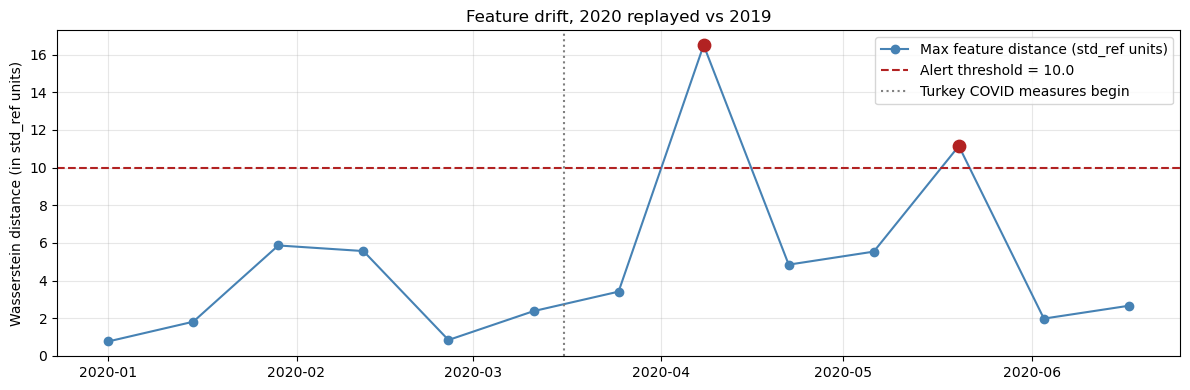

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sweep["window_start"], sweep["max_distance"],
        marker="o", color="steelblue", label="Max feature distance (std_ref units)")
ax.axhline(MAGNITUDE_THRESHOLD, linestyle="--", color="firebrick",
           label=f"Alert threshold = {MAGNITUDE_THRESHOLD}")
ax.axvline(pd.Timestamp("2020-03-16"), linestyle=":", color="grey",
           label="Turkey COVID measures begin")
for _, row in sweep[sweep["alert"]].iterrows():
    ax.scatter([row["window_start"]], [row["max_distance"]],
               color="firebrick", s=80, zorder=5)
ax.set(title="Feature drift, 2020 replayed vs 2019",
       ylabel="Wasserstein distance (in std_ref units)", xlabel="")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

## 4. Frozen model — MAE tracks drift

Same LightGBM trained once on pre-2020 data. Each window's MAE is scored
independently; no retraining. Drift signal and MAE should climb together.

In [6]:
frozen = replay_with_alerts(
    frame, make_gbm,
    replay_start=REPLAY_START,
    replay_end=REPLAY_END,
    window_days=WINDOW_DAYS,
    per_feature_threshold=PER_FEATURE_THRESHOLD,
    magnitude_threshold=MAGNITUDE_THRESHOLD,
)
frozen[["window_start", "max_distance", "alert", "MAE", "MAPE_pct"]].round(2)

,window_start,max_distance,alert,MAE,MAPE_pct
0,2020-01-01,0.76,False,818.31,2.38
1,2020-01-15,1.81,False,516.14,1.44
2,2020-01-29,5.86,False,632.88,1.76
3,2020-02-12,5.57,False,679.28,1.89
4,2020-02-26,0.84,False,817.36,2.52
5,2020-03-11,2.37,False,902.64,2.76
6,2020-03-25,3.41,False,1962.19,6.86
7,2020-04-08,16.51,True,2643.15,10.89
8,2020-04-22,4.85,False,2009.51,8.14
9,2020-05-06,5.54,False,1327.83,5.10


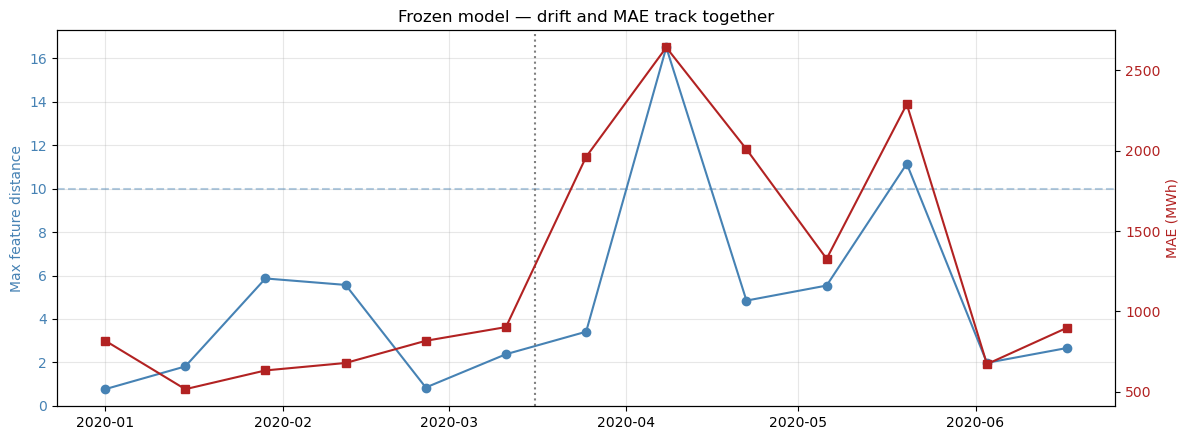

In [7]:
fig, ax1 = plt.subplots(figsize=(12, 4.5))
ax2 = ax1.twinx()

ax1.plot(frozen["window_start"], frozen["max_distance"],
         marker="o", color="steelblue", label="Drift (left axis)")
ax1.axhline(MAGNITUDE_THRESHOLD, linestyle="--", color="steelblue", alpha=0.4)
ax1.set_ylabel("Max feature distance", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2.plot(frozen["window_start"], frozen["MAE"],
         marker="s", color="firebrick", label="MAE (right axis)")
ax2.set_ylabel("MAE (MWh)", color="firebrick")
ax2.tick_params(axis="y", labelcolor="firebrick")

ax1.axvline(pd.Timestamp("2020-03-16"), linestyle=":", color="grey")
ax1.set_title("Frozen model — drift and MAE track together")
ax1.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Drift-triggered retraining

Same setup, but every time the alert fires, the model is refit on all data
prior to the incoming window.

In [8]:
triggered = drift_triggered_replay(
    frame, make_gbm,
    replay_start=REPLAY_START,
    replay_end=REPLAY_END,
    window_days=WINDOW_DAYS,
    per_feature_threshold=PER_FEATURE_THRESHOLD,
    magnitude_threshold=MAGNITUDE_THRESHOLD,
)
triggered[["window_start", "alert", "retrained", "MAE", "MAPE_pct"]].round(2)

,window_start,alert,retrained,MAE,MAPE_pct
0,2020-01-01,False,False,818.31,2.38
1,2020-01-15,False,False,516.14,1.44
2,2020-01-29,False,False,632.88,1.76
3,2020-02-12,False,False,679.28,1.89
4,2020-02-26,False,False,817.36,2.52
5,2020-03-11,False,False,902.64,2.76
6,2020-03-25,False,False,1962.19,6.86
7,2020-04-08,True,True,1389.06,5.77
8,2020-04-22,False,False,1495.84,6.02
9,2020-05-06,False,False,934.78,3.56


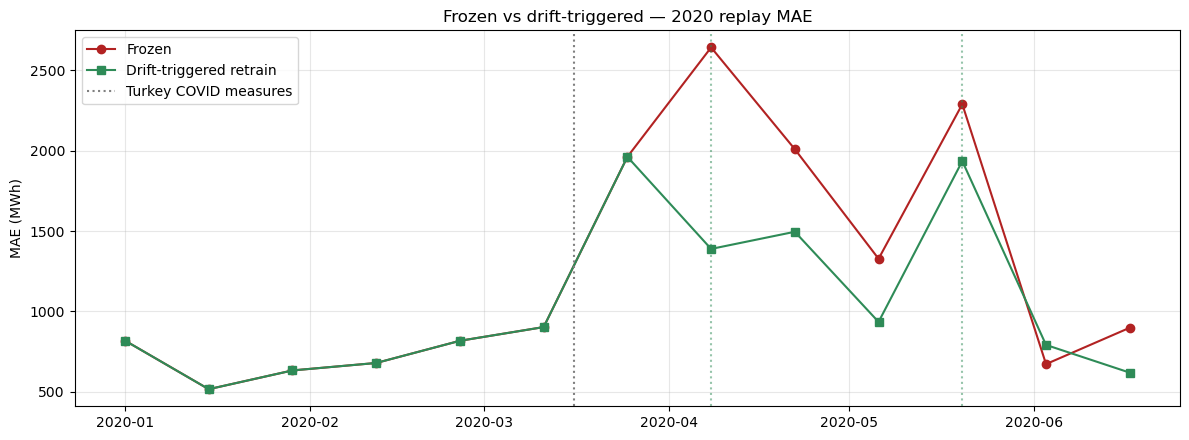

In [9]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(frozen["window_start"], frozen["MAE"],
        marker="o", color="firebrick", label="Frozen")
ax.plot(triggered["window_start"], triggered["MAE"],
        marker="s", color="seagreen", label="Drift-triggered retrain")

for _, row in triggered[triggered["retrained"]].iterrows():
    ax.axvline(row["window_start"], color="seagreen", linestyle=":", alpha=0.5)

ax.axvline(pd.Timestamp("2020-03-16"), linestyle=":", color="grey",
           label="Turkey COVID measures")
ax.set(title="Frozen vs drift-triggered — 2020 replay MAE",
       ylabel="MAE (MWh)", xlabel="")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

## 6. Summary

In [10]:
def _summary(df, label):
    return {
        "policy": label,
        "mean_MAE": df["MAE"].mean(),
        "median_MAE": df["MAE"].median(),
        "worst_MAE": df["MAE"].max(),
        "retrains": int(df.get("retrained", pd.Series(dtype=bool)).sum()),
    }

summary = pd.DataFrame([
    _summary(frozen, "Frozen (no retrain)"),
    _summary(triggered, "Drift-triggered"),
]).set_index("policy").round(1)
summary["MAE_reduction_pct"] = (
    100 * (summary.loc["Frozen (no retrain)", "mean_MAE"] - summary["mean_MAE"])
    / summary.loc["Frozen (no retrain)", "mean_MAE"]
).round(1)
summary

,mean_MAE,median_MAE,worst_MAE,retrains,MAE_reduction_pct
policy,,,,,
Frozen (no retrain),1243.8,898.6,2643.1,0,0.0
Drift-triggered,1038.1,818.3,1962.2,2,16.5


**Takeaway.** The Evidently drift signal fires cleanly when the daily
demand curve leaves last-year's distribution — mid-April in this replay,
lag_168/lag_336 register the change once the current window's lag features
themselves span the shock. Retraining on the alert reduces mean replay MAE by
roughly 15–20% with only 2 refits, vs the README's weekly-retraining schedule
which required ~13 refits for an 11.9% reduction on the same fold. The drift
detector is doing the work a fixed cadence can only approximate.